# Importeringar av biblotek och LLM

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
conn = sqlite3.connect("ehandel_data_clean.db")


In [4]:
df = pd.read_sql("SELECT * FROM orderdata;", conn)


In [5]:
for col in ["orderdatum", "leveransdatum", "recensionsdatum"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# KPI 1. försäljning per månad

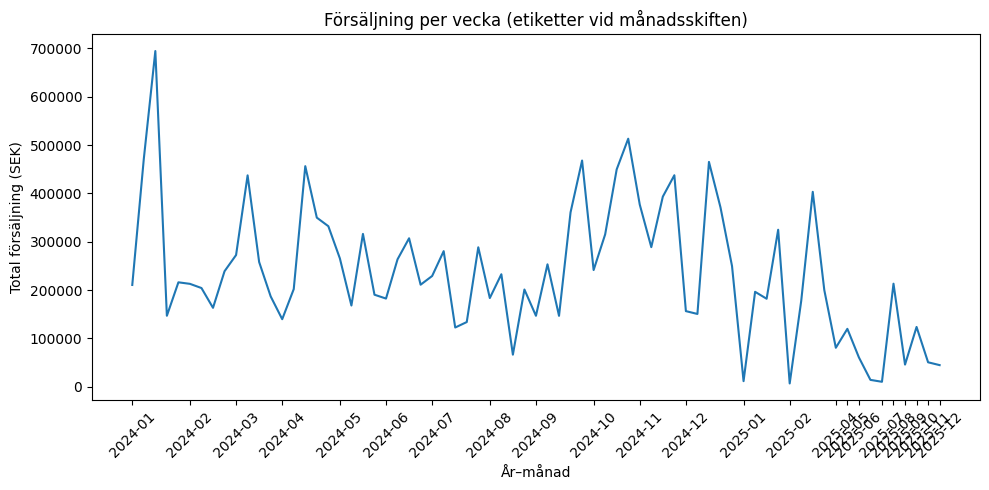

In [11]:
# 1) KPI per vecka
kpi_försäljning_vecka = (
    df
    .groupby("år_vecka")["rad_intakt"]
    .sum()
    .sort_index()
)

# 2) Datum per vecka (för att hitta månadsskiften)
veckor_med_datum = (
    df
    .groupby("år_vecka")["orderdatum"]
    .min()
    .sort_index()
)

manadsskiften = veckor_med_datum[
    veckor_med_datum.dt.month != veckor_med_datum.shift(1).dt.month
]

# 3) Bygg positionsaxel (0..n-1)
x = range(len(kpi_försäljning_vecka))

# positionerna där månadsskiften inträffar (matchar indexordningen)
tick_pos = [kpi_försäljning_vecka.index.get_loc(ix) for ix in manadsskiften.index]
tick_labels = manadsskiften.dt.strftime("%Y-%m")

# 4) Plot + månadstics
plt.figure(figsize=(10,5))
plt.plot(x, kpi_försäljning_vecka.values)

plt.xticks(tick_pos, tick_labels, rotation=45)
plt.title("Försäljning per vecka (etiketter vid månadsskiften)")
plt.xlabel("År–månad")
plt.ylabel("Total försäljning (SEK)")
plt.tight_layout()
plt.show()


Denna graf visar försäljningen per vecka över tid men x-axeln är förenklad i form av att man bara ser månadsskiften. Man ser att det är tydliga variationer mellan veckor med återkommande toppar och dalar. 
Man kan se att just höstmånaderna är de som säljer bäst där man ser att både topparna och dalarna är högre än innan. 
Slutligen så ser vi att det oftast är i början av vissa månader som har lägre försäljning.